# Butterworth Tiefpassfilter

In diesem Jupyter Notebook wird als Beispiel ein Butterworth Tiefpassfilter 4.ter Ordnung mit einer Grenzfrequenz von 5 Hz realisiert.

Anwendungsbeispiel: Filterung des Beschleunigungssignals eines Referenzbeschleunigungssensors bei Bremsversuchen

Inhalt:
- Berechnung der Butterworth-Filterkoeffizienten
- Frequenzgang eines Butterworth-Tiefpassfilters (1. bis 4. Ordnung)
- Realisierung des Filters 
   - als lineares kausales Filter 
   - als lineares nicht kausales Filter (keine Phasenverschiebung bzw. Verzögerung)
- Antwort des Filters auf Sinussingal-Eingang
- Spruntantwort des Filters
- Frequenzgang des Filters



Es werden folgende Funktionen aus dem scipy Python Package verwendet:

- Butterworth-Filterkoeffizienten berechnen: [`scipy.signal.butter()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html)
- lineares kausales Filter berechnen: [`scipy.signal.lfilter()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lfilter.html)
- lineares Filter vorwärts und rückwärts berechnen: [`scipy.signal.filtfilt()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.filtfilt.html)
- Frequenzgang berechnen: [`scipy.signal.freqz()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.freqz.html)





----
2026-06-07 ug V1.2

In [2]:
import numpy as np 
import scipy.signal as signal  
from matplotlib import pyplot as plt
%matplotlib inline

### Definition des Filters

- Butterworth-Filterkoeffizienten berechnen: [`scipy.signal.butter()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html)
- lineares kausales Filter berechnen: [`scipy.signal.lfilter()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lfilter.html)
- lineares Filter vorwärts und rückwärts berechnen: [`scipy.signal.filtfilt()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.filtfilt.html)
- Frequenzgang berechnen: [`scipy.signal.freqz()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.freqz.html)

In [3]:
def LPF_butter(input_signal, dT, fg = 5.0, n_order  = 4, mode='causal'):
    '''
        Low pass filter, butterworth characteristic, 4th order, corner frequency 5 Hz 
        input:  input_signal    input signal as np array 
                dT              sampling time
                n_order  = 4    filter order of butterworth filter
                f0 = 5.0        -3dB corner frequency [Hz] of butterworth filter
                mode = 'causal'      filter response with delay - only past input signal values are used
                       'zero-phase'  filter response without delay - also future input signal values are used
                       'coeff'       digital filter coefficients 
        return: filtered signal as np array  
    '''

    fs = 1.0/dT         # sampling frequency (assumption: constant sampling interval)
    f_nyq = fs/2.0      # Nyquist frequency (= 1/2 sampling frequency)
    Wn = fg/f_nyq       # normalized corner frequency  (related to Nyquist frequency)
  
    # Filterkoeffizienten berechnen
    B,A = signal.butter(n_order, Wn)
 
    # Filter berechnen
    if mode== 'causal':
        return signal.lfilter(B,A,input_signal)
    elif mode == 'zero-phase':
        return signal.filtfilt(B, A, input_signal, padlen=150)  # padlen=150 verbessert das Einschwingen des Filters
    elif mode == 'coeff':
        return B, A
         


---
### Frequenzgang eines Butterworth-Tiefpassfilters (1. bis 4. Ordnung)

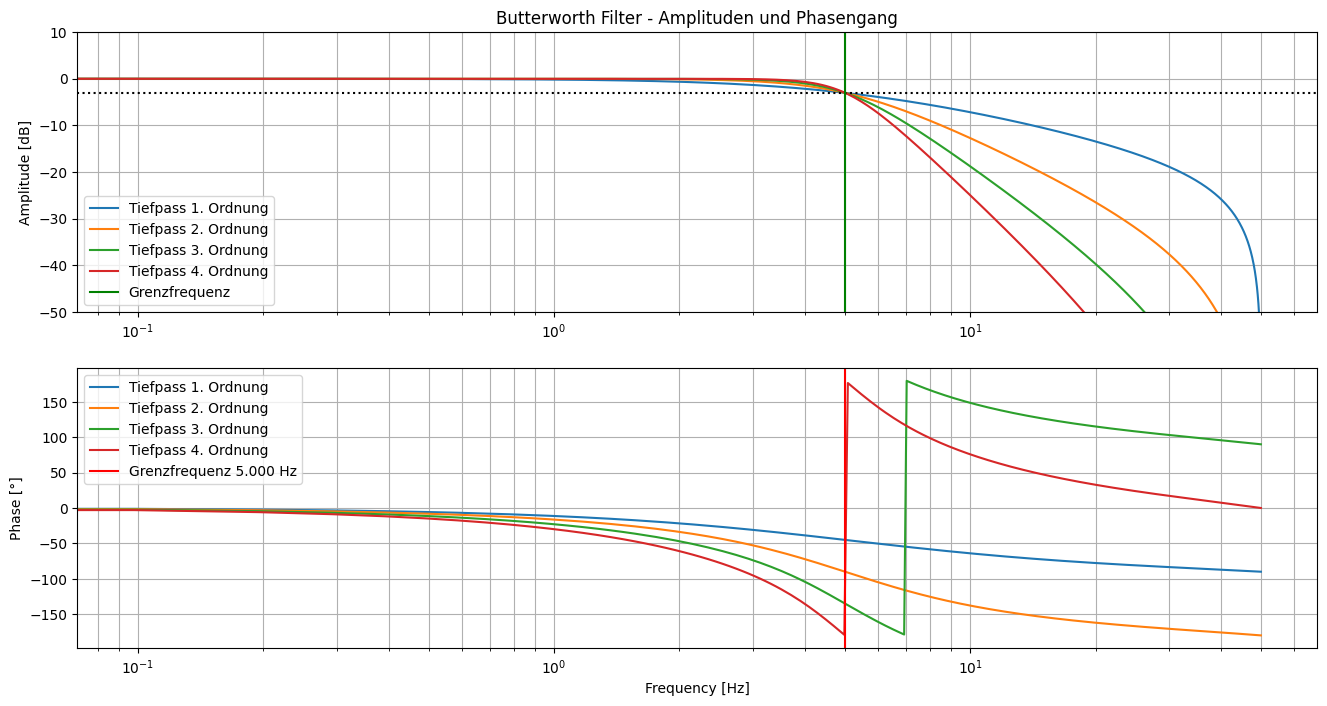

In [4]:
fig, (ax1,ax2) = plt.subplots(nrows=2, figsize=(16,8))

dT = 0.01        # Abtastzeit in Sekunden
fg = 5.0         # Grenzfrequenz in Hz

fs = 1.0/dT         # sampling frequency (assumption: constant sampling interval)
f_nyq = fs/2.0      # Nyquist frequency (= 1/2 sampling frequency)


h = {} # Amplitudengang für verschiedene Filterordnungen
for n_order in range(1,5):
    B, A = LPF_butter(None,dT, fg = fg,  n_order = n_order, mode='coeff') # Filterkoeffizienten berechnen
    w,h[n_order] = signal.freqz(B, A) # Frequenzgang des Filters berechnen


# w ist eine normierte Frequenz und geht von 0 bis pi; pi entspricht der Nyquistfrequenz
f = w/np.pi*f_nyq

# Amplitudengang
for key,value in h.items():
    ax1.semilogx(f, 20 * np.log10(abs(value)),label=f'Tiefpass {key}. Ordnung')

ax1.axhline(-3.0, color='black',ls=':')
ax1.axvline(fg, color='green', label='Grenzfrequenz')
ax1.set_ylim(-50,10)

ax1.set_title('Butterworth Filter - Amplituden und Phasengang')
ax1.set_ylabel('Amplitude [dB]')
ax1.legend()

#plt.margins(0, 0.1)
ax1.grid(which='both', axis='both')

#  Phasengang
for key,value in h.items():
    ax2.semilogx(f, np.angle(value,deg=True),label=f'Tiefpass {key}. Ordnung')
ax2.axvline(fg, color='red', label=f'Grenzfrequenz {fg:.3f} Hz') 
ax2.grid(which='both', axis='both')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Phase [°]')
ax2.legend();


---
### Erzeugen eines Testsignals (Sinussignal)

Es wird ein Sinussignal mit der Frequenz von 5 Hz und einer Abtastfrequenz von 100Hz erzeugt.
<br>
Die Frequenz von 5 Hz ist auch die Grenzfrequenz (corner frequency) des Filter.
<br>
Bei der Grenzfrequenz geht die Ausgangsamplitude auf um 3dB auf 0.707 der Eingangsamplitude zurück. (Filterwirkung)


In [5]:
N = 200      # Anzahl der Abtastpunkt    
dT = 0.01    # Abtastzeit -> Abtastfrequenz = 1/Abtastzeit

print(f"Abtastfrequenz: {1/dT} Hz")

# Zeitsignal
t = np.arange(0,N*dT,dT)

# Testsignal: Sinussignal mit der Amplitude 1.0 und Frequenz 5.0 Hz
Ampl = 1.0
f0 = 5.0
input_signal = Ampl*np.sin(2*np.pi*f0*t)

Abtastfrequenz: 100.0 Hz


####  Test Signal plotten

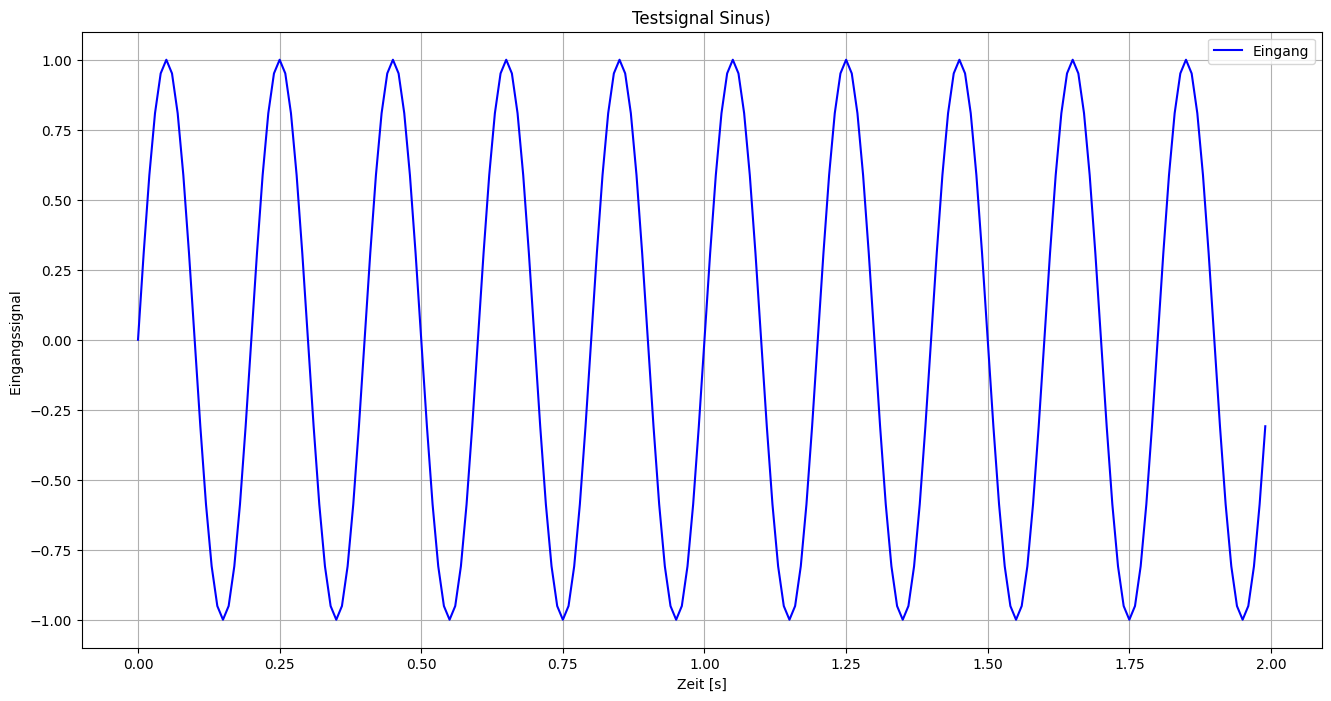

In [6]:
fig, ax1 = plt.subplots(figsize=(16,8))

ax1.set_title('Testsignal Sinus)')
ax1.plot(t,input_signal,color='b',label='Eingang')

ax1.set_ylim((-1.1,1.1))
ax1.grid()
ax1.set_xlabel('Zeit [s]')
ax1.set_ylabel('Eingangssignal ')
ax1.legend();


### Filter auf Testsignal anwenden

In [7]:
output_signal = LPF_butter(input_signal, dT)

### Ein-/Ausgangssignale darstellen

In [8]:
def plot_Sinus_Ein_und_Ausgang(t,input_signal,output_signal):
    fig, ax1 = plt.subplots(figsize=(16,8))

    ax1.set_title('Example Low Pass Filter 5 Hz (Butterworth 4th order)')
    ax1.plot(t,input_signal,color='b',label='Eingang')
    ax1.plot(t,output_signal,color='r',label='Ausgang')
    ax1.plot(t,np.ones_like(t)*1.0/np.sqrt(2.0),color='m',ls='--',label='3dB Abschwächung')    # -3dB = 1/sqrt(2) = 0.707
    ax1.plot(t,np.ones_like(t)*-1.0/np.sqrt(2.0),color='m',ls='--')                            # -3dB = 1/sqrt(2) = 0.707

    ax1.plot(t,np.ones_like(t)*1.0/2.0,color='k',ls='--',label='6dB Abschwächung')    # -6dB = 1/2 = 0.5
    ax1.plot(t,np.ones_like(t)*-1.0/2.0,color='k',ls='--')                            # -6dB = 1/2 = 0.5

    ax1.set_ylim((-1.1,1.1))
    ax1.grid()
    ax1.set_xlabel('Zeit [s]')
    ax1.set_ylabel('Ein-/Ausgangssignal ')
    ax1.legend();


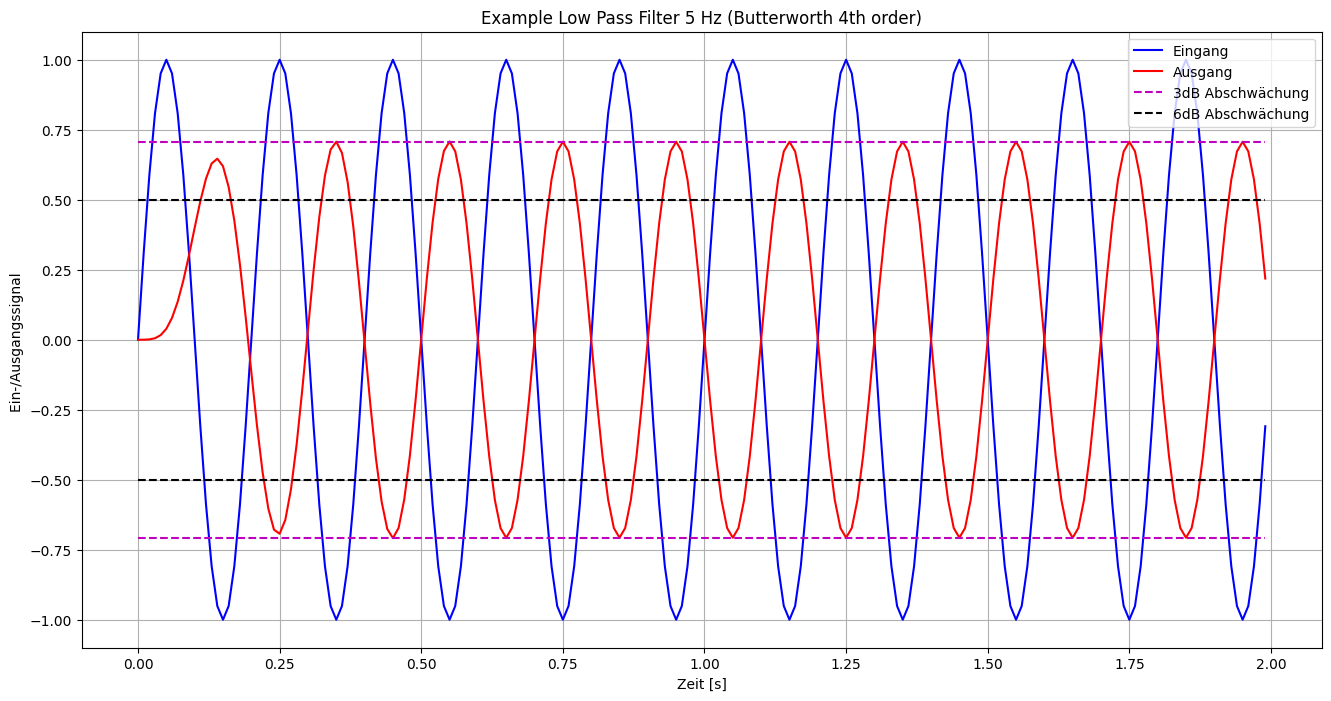

In [9]:
plot_Sinus_Ein_und_Ausgang(t,input_signal,output_signal)

#### nicht kausales Filter ohne Verzögerung

In [10]:
output_signal = LPF_butter(input_signal, dT, n_order= 4, mode='zero-phase')

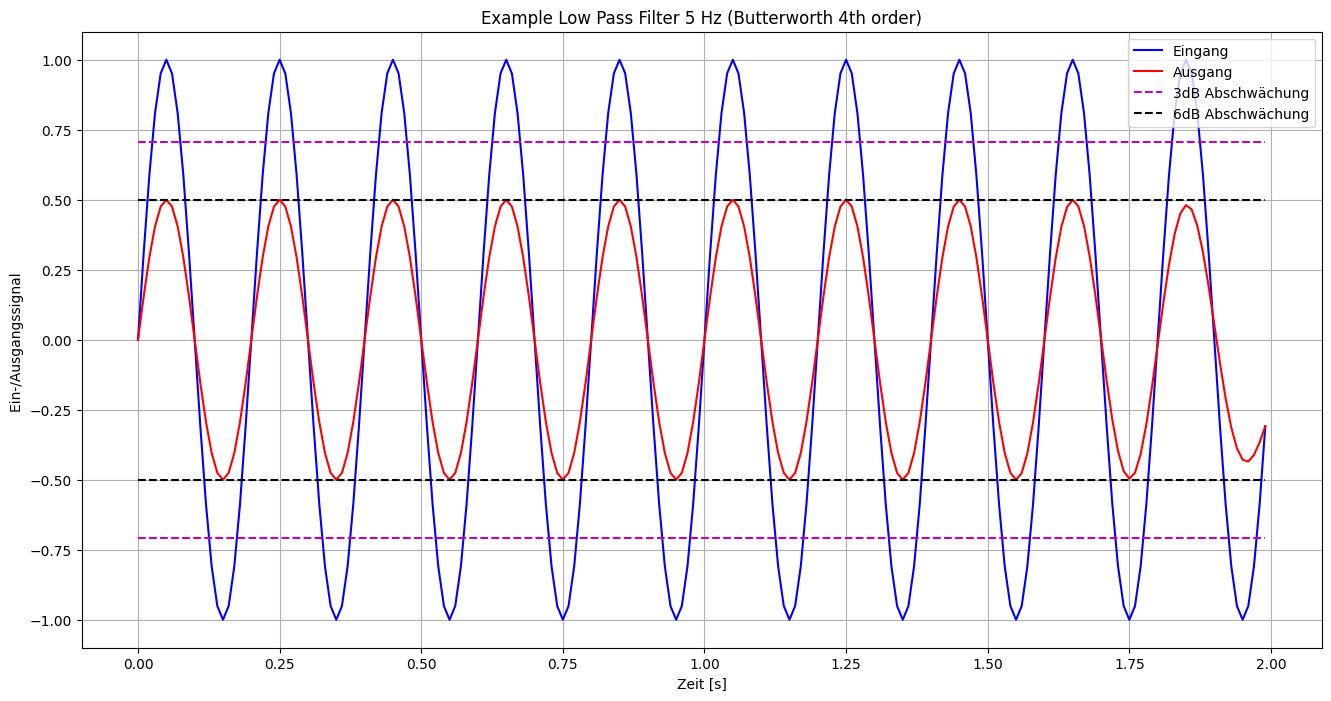

In [11]:
plot_Sinus_Ein_und_Ausgang(t,input_signal,output_signal)

Das Ausgangssignal ist um 6dB gegenüber dem Eingangssignal abgeschwächt worden.
<br>
Dies kommt dadurch zustande, dass der Tiefpassfilter zweimal durchlaufen wird, einmal in zeitlich normaler Richtung und einmal in zeitlich umgekehrter Richtung. 
<br>
Dadurch hebt sich die Phasenverschiebung auf und die Filterwirkung verdoppelt sich. 

---
### Sprungantwort

In [12]:
N = 200
dT = 0.005  # diesmal eine höhere Abtastfrequenz wählen

print(f"Abtastfrequenz: {1/dT} Hz")

# Zeitsignal
t = np.arange(0,N*dT,dT)

# Sprung auf 1 
t_start_step = 0.3

input_signal = np.zeros_like(t)
input_signal[t>t_start_step] = 1.0

Abtastfrequenz: 200.0 Hz


#### Testsignal plotten

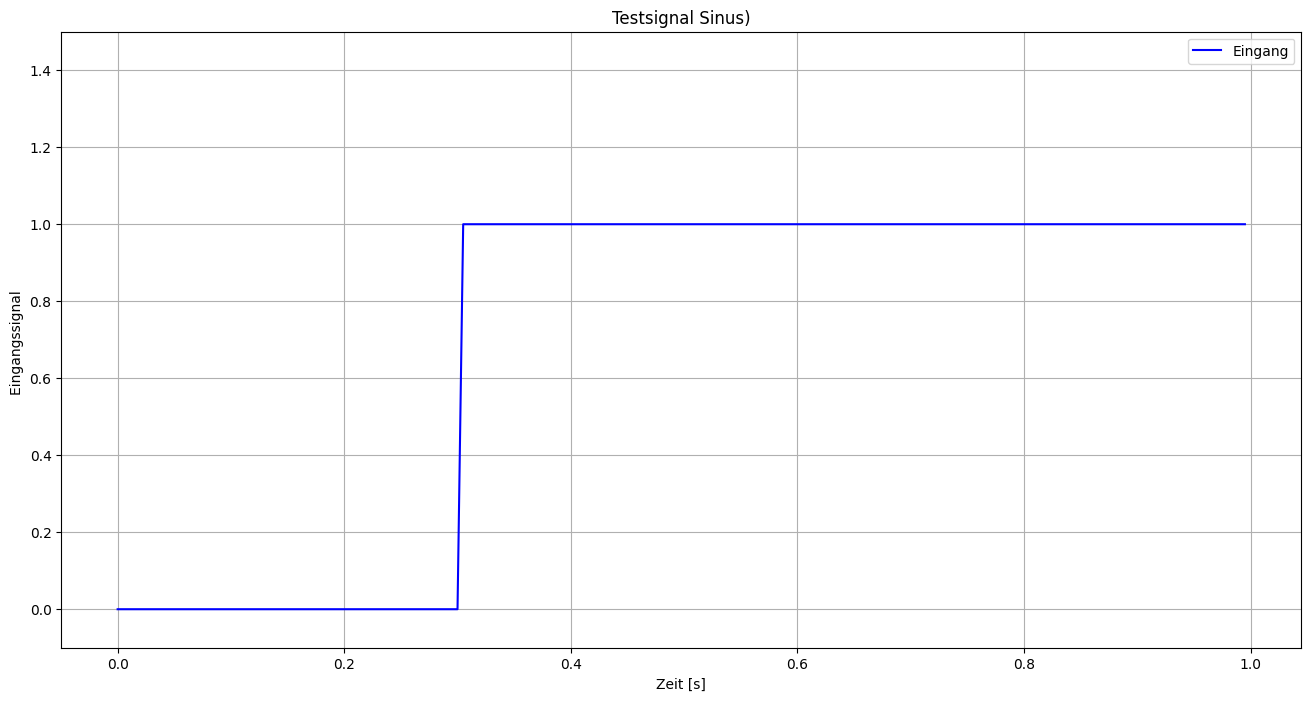

In [13]:
fig, ax1 = plt.subplots(figsize=(16,8))

ax1.set_title('Testsignal Sinus)')
ax1.plot(t,input_signal,color='b',label='Eingang')

ax1.set_ylim((-0.1, 1.5))
ax1.grid()
ax1.set_xlabel('Zeit [s]')
ax1.set_ylabel('Eingangssignal ')
ax1.legend();

### Filter auf Testsignal anwenden

In [14]:
output_signal = LPF_butter(input_signal,dT)

### Ein-/Ausgangssignale darstellen

In [15]:
def plot_sprung(t,input_signal,output_signal,t_start_step):
    fig, ax1 = plt.subplots(figsize=(16,8))

    x_min_plot = -0.3
    
    t_10 = t[output_signal>=0.1][0]-t_start_step
    print(f"t bis auf 10% der Amplitude {t_10:.3f} s")
    t_50 = t[output_signal>=0.5][0]-t_start_step
    print(f"t bis auf 50% der Amplitude {t_50:.3f} s")
    t_63 = t[output_signal>=0.63][0]-t_start_step
    print(f"t bis auf 63% der Amplitude {t_63:.3f} s")
    t_90 = t[output_signal>=0.9][0]-t_start_step
    print(f"t bis auf 90% der Amplitude {t_90:.3f} s")

    ax1.set_title("Example Low Pass Filter 5 Hz (Butterworth 4th order)")
    ax1.plot(t - t_start_step,input_signal,color='b',label='Eingang')
    ax1.plot(t - t_start_step,output_signal,color='r',label='Ausgang')
    
    ax1.plot([x_min_plot, t_90], [0.9, 0.9],  color='m',ls='--',label=f'90% - {t_90:.3f} s') 
    ax1.plot([t_90,t_90], [0, 0.9],  color='m',ls='--') 
    
    ax1.plot([x_min_plot, t_63], [0.63, 0.63], color='m',ls='--',label=f'63% - {t_63:.3f} s') 
    ax1.plot([t_63,t_63], [0, 0.63],  color='m',ls='--') 
    
    ax1.plot([x_min_plot, t_50], [0.5, 0.5],  color='m',ls='--',label=f'50% - {t_50:.3f} s')  
    ax1.plot([t_50,t_50], [0, 0.5],  color='m',ls='--') 
    
    ax1.plot([x_min_plot, t_10], [0.1, 0.1],  color='m',ls='--',label=f'10% - {t_10:.3f} s')  
    ax1.plot([t_10,t_10], [0, 0.1],  color='m',ls='--') 
    

    ax1.set_ylim((-0.1, 1.5))
    ax1.set_xlim((x_min_plot, 0.6))
    ax1.grid()
    ax1.set_xlabel('Zeit [s]')
    ax1.set_ylabel('Ein-/Ausgangssignal ')
    ax1.legend();

t bis auf 10% der Amplitude 0.055 s
t bis auf 50% der Amplitude 0.095 s
t bis auf 63% der Amplitude 0.105 s
t bis auf 90% der Amplitude 0.130 s


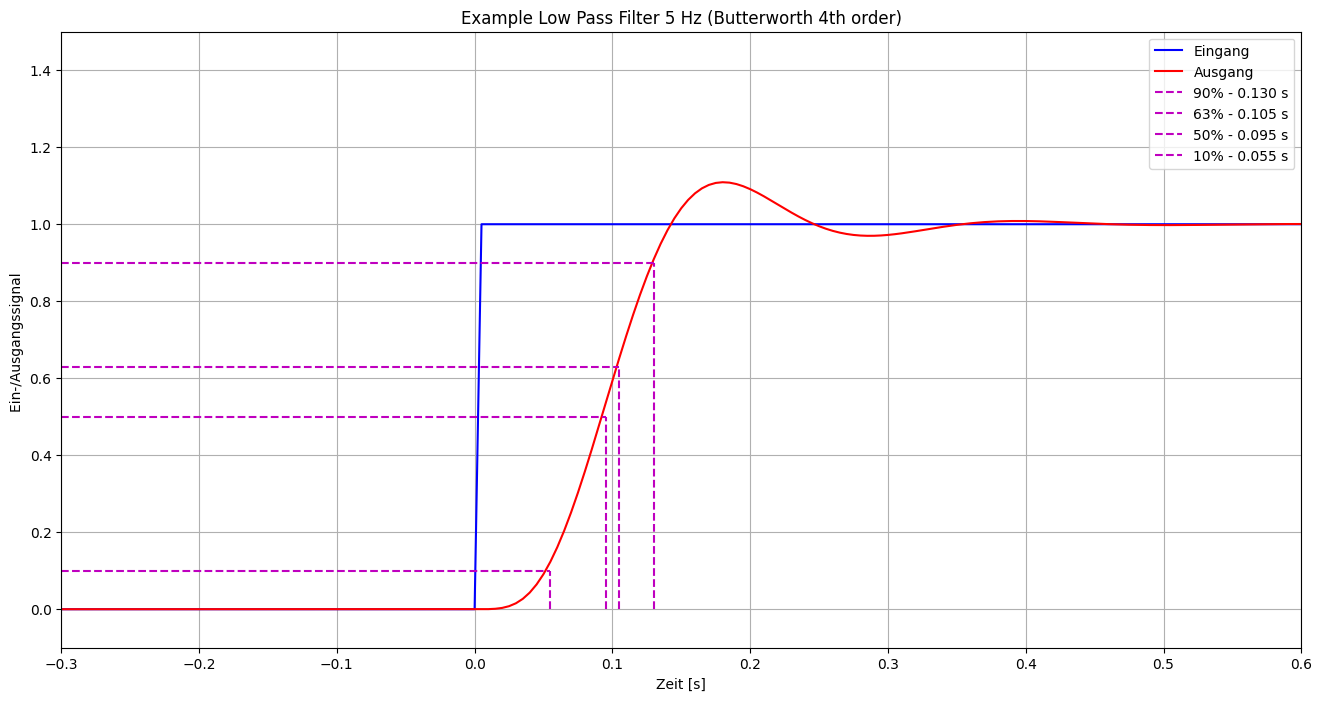

In [16]:
plot_sprung(t,input_signal,output_signal,t_start_step)

#### nicht kausales Filter ohne Verzögerung

In [17]:
output_signal = LPF_butter(input_signal, dT, n_order = 4,mode='zero-phase')

t bis auf 10% der Amplitude -0.040 s
t bis auf 50% der Amplitude 0.005 s
t bis auf 63% der Amplitude 0.020 s
t bis auf 90% der Amplitude 0.050 s


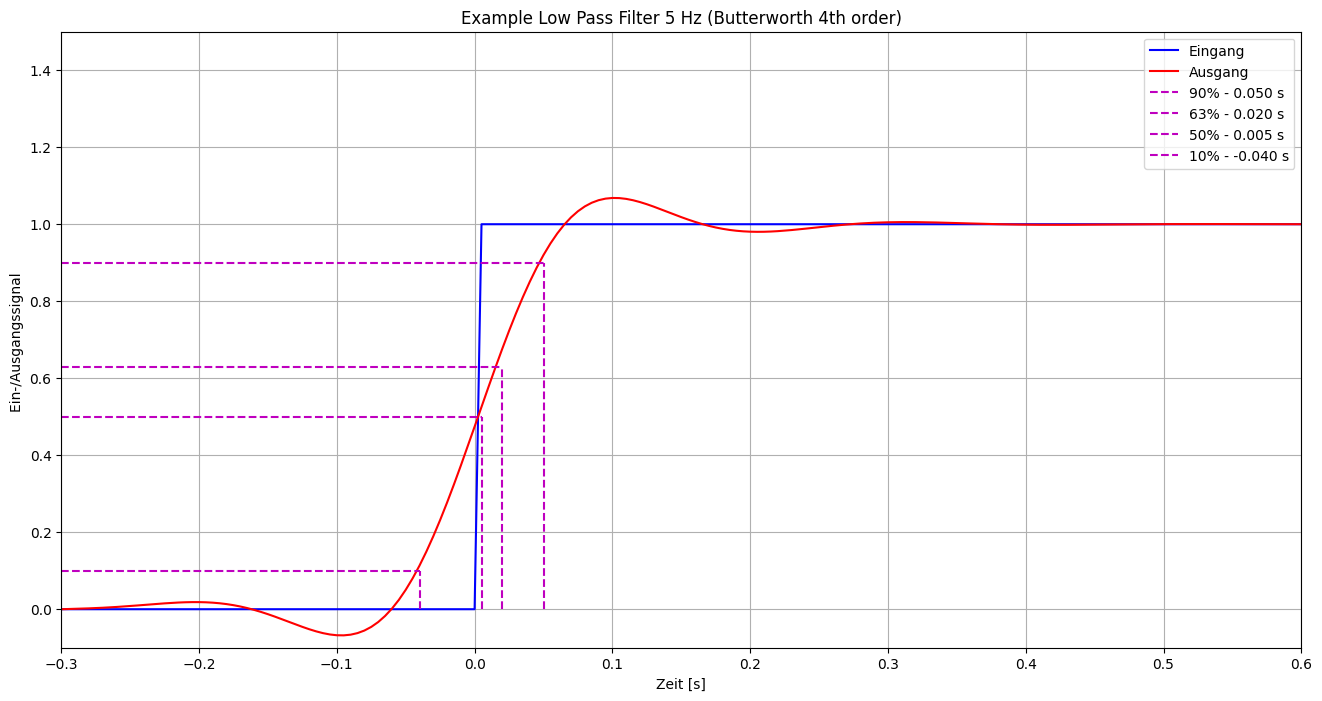

In [18]:
plot_sprung(t,input_signal,output_signal,t_start_step)

Auch hier sieht man sehr deutlich, dass die Sprungantwort deutlich vor dem Sprung am Eingang auftritt.
<br>
Dies ist ein nicht-kausales Verhalten, weil die Antwort vor der Änderung am Eingang startet.